예제 8.4 DCGAN(텐서플로)

In [ ]:
# 예제 8.4 DCGAN CelebA(텐서플로)

# 데이터셋 다운로드
!mkdir celeba   # 저장할 폴더 생성
!wget "https://drive.google.com/uc?id=1up5bN8LCE2vHigVY-Z9yY2_aKRW5jN_9&confirm=t"\
 -O celeba/data.zip
!unzip -qq celeba/data.zip -d celeba   # 압축 해제

In [ ]:
# 셋업
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import BatchNormalization, ReLU, LeakyReLU
from tensorflow.keras.layers import Dense, Reshape, Flatten, Dropout
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython import display

In [ ]:
# 데이터셋 준비
dataset = tf.keras.utils.image_dataset_from_directory(
    directory="/content/celeba",   # 폴더 경로 지정
    label_mode=None,               # 레이블 사용하지 않음
    image_size=(64, 64),           # 이미지 크기(64x64)
    batch_size=32)                 # 배치 크기

print(f"length of dataset: {len(dataset)}")

# 소규모 CelebA 데이터셋 사용
dataset = dataset.take(313)   # 10,000개(32x313) 샘플

print(f"length of small dataset: {len(dataset)}")

Found 202599 files belonging to 1 classes.
length of dataset: 6332
length of small dataset: 313


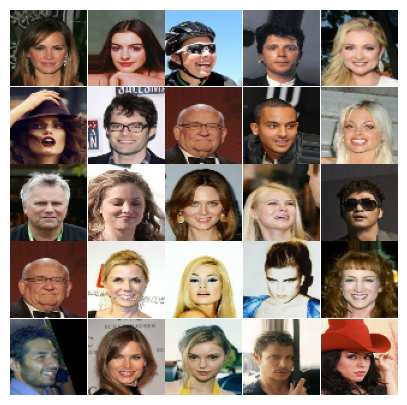

In [ ]:
# 학습 이미지 시각화
fig, axes = plt.subplots(5, 5, figsize=(5, 5),
                         gridspec_kw={'wspace':0.01, 'hspace':0.01})

for i, ax in enumerate(axes.ravel()):
    for imgs in dataset.take(1):
        ax.imshow(imgs[i] / 255.)   # 픽셀 값 (0 ~ 1) 변환
        ax.axis('off')

plt.show()

In [ ]:
# 정규화(-1 ~ 1)
dataset = dataset.map(lambda x: (x - 127.5) / 127.5)

In [ ]:
# 생성자 정의
generator = Sequential([
    Dense(4 * 4 * 512, input_shape=(100, )),
    BatchNormalization(),
    ReLU(),
    Reshape((4, 4, 512)),

    Conv2DTranspose(256, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv2DTranspose(128, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv2DTranspose(64, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv2DTranspose(3, kernel_size=4, strides=2, padding='same',
                    activation='tanh')],
    name='generator')

generator.summary()

Model: "generator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8192)              827392    
                                                                 
 batch_normalization (Batch  (None, 8192)              32768     
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 8192)              0         
                                                                 
 reshape (Reshape)           (None, 4, 4, 512)         0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 8, 8, 256)         2097408   
 anspose)                                                        
                                                                 
 batch_normalization_1 (Bat  (None, 8, 8, 256)         10

In [ ]:
# 판별자 정의
discriminator = Sequential([
    Conv2D(64, kernel_size=4, strides=2, padding='same',
           input_shape=(64, 64, 3)),
    LeakyReLU(alpha=0.2),

    Conv2D(128, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),

    Conv2D(256, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),

    Conv2D(512, kernel_size=4, strides=2, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.2),

    Flatten(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')],
    name='discriminator')

discriminator.summary()

Model: "discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        3136      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32, 32, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 128)       131200    
                                                                 
 batch_normalization_4 (Bat  (None, 16, 16, 128)       512       
 chNormalization)                                                
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 16, 16, 128)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 256)         524544    
                                                     

In [ ]:
# 하이퍼파라미터 설정
batch_size = 32    # 배치 크기
latent_dim = 100   # 랜덤 벡터 차원
num_generate = 9   # 생성할 이미지 수
seed = tf.random.normal([num_generate, latent_dim])   # 생성자 학습 시작 입력

# 손실 함수 설정
bce_loss = tf.keras.losses.BinaryCrossentropy()

# 옵티마이저 설정
g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [ ]:
# 학습 루프 함수 정의
@tf.function   # 함수를 그래프로 변환하여 속도 향상
def train_step(images):
    noise = tf.random.normal([batch_size, latent_dim])   # 랜덤 벡터

    # 판별자 학습
    with tf.GradientTape() as tape:   # 자동 미분 수행
        real_output = discriminator(images, training=True)
        fake_images = generator(noise, training=True)
        fake_output = discriminator(fake_images, training=True)

        real_loss = bce_loss(tf.ones_like(real_output), real_output)
        fake_loss = bce_loss(tf.zeros_like(fake_output), fake_output)
        d_loss = real_loss + fake_loss

    d_gradient = tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(
        zip(d_gradient, discriminator.trainable_variables))

    # 생성자 학습
    with tf.GradientTape() as tape:   # 자동 미분 수행
        fake_images = generator(noise, training=True)
        fake_output = discriminator(fake_images, training=True)
        g_loss = bce_loss(tf.ones_like(fake_output), fake_output)

    g_gradient = tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(
        zip(g_gradient, generator.trainable_variables))

In [ ]:
# 이미지 생성/저장 함수 정의
def generate_save_images(model, epoch, inputs):
    prediction = model(inputs, training=False)
    min = tf.reduce_min(prediction)
    max = tf.reduce_max(prediction)
    prediction = (prediction - min) / (max - min)  # 픽셀 값(0 ~ 1)

    fig = plt.figure(figsize=(5, 5))
    plt.subplots_adjust(wspace=0.01, hspace=0.01)

    for i in range(prediction.shape[0]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(prediction[i])
        plt.axis('off')

    plt.savefig(f"image at epoch {epoch}.png")

    plt.show()

In [ ]:
# 학습 함수 정의
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)

        # 에포크마다 이미지 생성
        display.clear_output(wait=True)
        print(f"Generated Images at Epoch {epoch + 1}")
        generate_save_images(generator, epoch + 1, seed)

Generated Images at Epoch 20


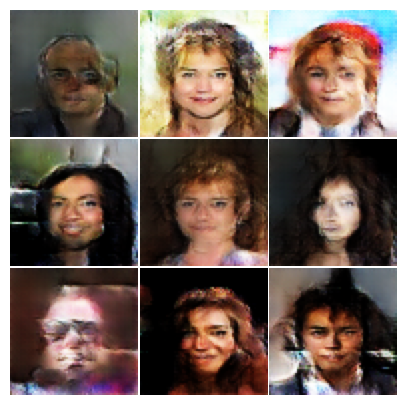

In [ ]:
# 학습(이미지 생성)
train(dataset, epochs=20)

Generated Images at Epoch 1


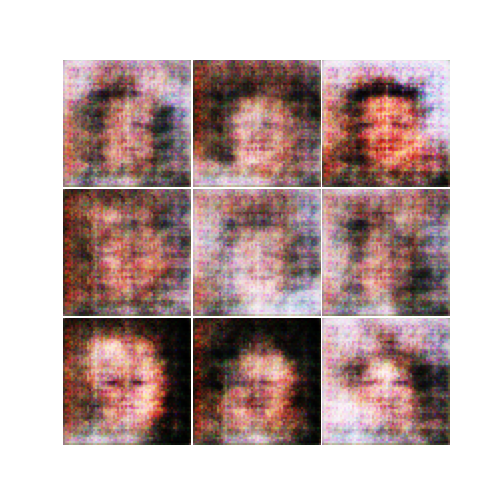

In [ ]:
# 에포크 별 생성 이미지 확인
def display_image(epoch_no):
    print(f"Generated Images at Epoch {epoch_no}")
    return Image.open(f"image at epoch {epoch_no}.png")

display_image(epoch_no=1)

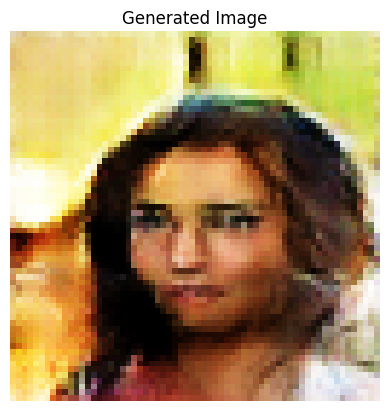

In [ ]:
# 생성 이미지 확인
tf.random.set_seed(7)

noise = tf.random.normal([1, 100])
generated_image = generator(noise)
min = tf.reduce_min(generated_image)
max = tf.reduce_max(generated_image)
generated_image = (generated_image - min) / (max - min)  # 픽셀 값(0 ~ 1)

plt.imshow(generated_image[0])
plt.title('Generated Image')
plt.axis('off')

plt.show()

In [ ]:
# 모델 저장
generator.save(
    '/content/drive/MyDrive/Colab Notebooks/models/small_celeba_gan.h5')

In [ ]:
# 모델 불러오기
generator = tf.keras.models.load_model(
    '/content/drive/MyDrive/Colab Notebooks/models/small_celeba_gan.h5')